In [2]:
!pip3 install segmentation-models-pytorch

    100% |################################| 102kB 2.3MB/s a 0:00:01
    100% |################################| 378kB 808kB/s eta 0:00:01
    100% |################################| 81kB 2.4MB/s eta 0:00:01
    100% |################################| 61kB 2.5MB/s eta 0:00:01
  Running setup.py bdist_wheel for efficientnet-pytorch ... done
  Stored in directory: /root/.cache/pip/wheels/84/27/aa/c46d23c4e8cc72d41283862b1437e0b3ad318417e8ed7d5921
  Running setup.py bdist_wheel for pretrainedmodels ... done
  Stored in directory: /root/.cache/pip/wheels/69/df/63/62583c096289713f22db605aa2334de5b591d59861a02c2ecd
Successfully built efficientnet-pytorch pretrainedmodels


In [5]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from pathlib import Path
from PIL import Image
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset
import cv2
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.models.segmentation import fcn_resnet50
import torch.nn as nn
import segmentation_models_pytorch as smp
from tqdm import tqdm
import pandas as pd
import numpy as np
import time

from utils.lichen_dataset import LichenDataset


In [6]:
device = "cuda"

In [7]:
test_images = "/workspace/data_HITL/test/test_images"
test_masks = "/workspace/data_HITL/test/test_masks"

In [8]:
test_dataset = LichenDataset(
    image_dir=test_images,
    mask_dir=test_masks,
    image_size=512
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0
)

Number of pairs found: 50


In [11]:
model = smp.Unet(
    encoder_name="mobilenet_v2",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

weights_path = "/workspace/weights_HITL/2unet_mobilenetv2_lichen.pth"

state_dict = torch.load(weights_path, map_location=device)
model.load_state_dict(state_dict)

model = model.to(device)
model.eval()

Unet(
  (encoder): MobileNetV2Encoder(
    (features): Sequential(
      (0): ConvBNActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): ConvBNActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): ConvBNActivation(
            (0): Conv2d(16, 96, kernel_size=(1, 1), stride

In [12]:
def compute_metrics(pred, mask, eps=1e-7):
    pred = pred.bool()
    mask = mask.bool()

    tp = (pred & mask).sum().item()
    fp = (pred & ~mask).sum().item()
    fn = (~pred & mask).sum().item()
    tn = (~pred & ~mask).sum().item()

    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    accuracy = (tp + tn) / (tp + tn + fp + fn + eps)

    return {
        "iou": iou,
        "dice": dice,
        "precision": precision,
        "recall": recall,
        "accuracy": accuracy
    }

In [13]:
all_metrics = []
latencies = []

threshold = 0.5

with torch.no_grad():
    for images, masks, names in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        if device == "cuda":
            torch.cuda.synchronize()

        start = time.time()

        logits = model(images)
        probs = torch.sigmoid(logits)
        preds = probs > threshold

        if device == "cuda":
            torch.cuda.synchronize()

        end = time.time()

        latency = end - start
        latencies.append(latency)

        metrics = compute_metrics(preds.cpu(), masks.cpu())
        metrics["filename"] = names[0]
        metrics["latency_sec"] = latency

        all_metrics.append(metrics)

In [14]:
df = pd.DataFrame(all_metrics)
df.head()

,iou,dice,precision,recall,accuracy,filename,latency_sec
0,0.656642,0.792738,0.672390,0.965559,0.841518,lichen_11032703,81.674981
1,0.422534,0.594058,0.914532,0.439905,0.640408,lichen_297012592,2.380503
2,0.747778,0.855690,0.918118,0.801212,0.787460,lichen_265585502,1.722758
3,0.203131,0.337670,0.269448,0.452152,0.854557,lichen_74735136,2.594696
4,0.043064,0.082572,0.788607,0.043567,0.610409,lichen_181096723,0.486444


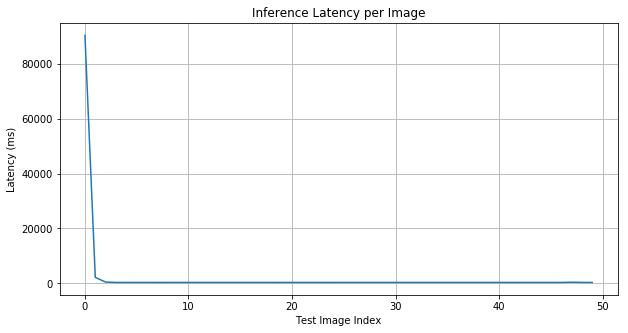

In [14]:
latencies_ms = [x * 1000 for x in latencies]

plt.figure(figsize=(10,5))

plt.plot(latencies_ms)

plt.xlabel("Test Image Index")
plt.ylabel("Latency (ms)")
plt.title("Inference Latency per Image")

plt.grid(True)

plt.show()

In [15]:
df.mean(numeric_only=True)

iou            0.548163
dice           0.671414
precision      0.781629
recall         0.681157
accuracy       0.828121
latency_sec    2.084945
dtype: float64

In [15]:
df

,iou,dice,precision,recall,accuracy,filename,latency_sec
0,0.688506,0.815521,0.710303,0.957331,0.864048,lichen_11032703,90.365628
1,0.481409,0.649934,0.860830,0.522039,0.663643,lichen_297012592,2.187294
2,0.754423,0.860024,0.911970,0.813677,0.791691,lichen_265585502,0.477673
3,0.189576,0.318729,0.239699,0.475506,0.833321,lichen_74735136,0.345435
4,0.505619,0.671642,0.982886,0.510110,0.799282,lichen_181096723,0.346902
5,0.393405,0.564667,0.650128,0.499064,0.872986,lichen_41813255,0.344706
6,0.862357,0.926092,0.883406,0.973112,0.949184,lichen_141767571,0.346366
7,0.407630,0.579172,0.933181,0.419886,0.708050,lichen_34608861,0.344842
8,0.571163,0.727058,0.607359,0.905519,0.839581,lichen_93036882,0.344714
9,0.854592,0.921596,0.965682,0.881359,0.920788,lichen_37456823,0.344945
